In [13]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import csv
import time
from urllib.parse import urljoin
import re
from datetime import datetime, timedelta
import time
import warnings
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

All libraries imported successfully!
Current date: 2025-12-06


In [7]:
def scrape_soidb(csv_filename):
    urls = [
        "https://www.soidb.com/bangkok/fire/list.html",
        "https://www.soidb.com/bangkok/police/list.html",
        "https://www.soidb.com/bangkok/government/list.html"
    ]
    headers = ["name", "road", "district", "province"]
    
    request_headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    with open(csv_filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(headers)

        for start_url in urls:
            print(f"--- Starting Category: {start_url} ---")
            current_url = start_url
            
            while True:
                print(f"Scraping: {current_url}")
                try:
                    response = requests.get(current_url, headers=request_headers, timeout=10)
                    if response.status_code != 200:
                        print(f"Failed to load page: {response.status_code}")
                        break

                    soup = BeautifulSoup(response.content, "html.parser")

                    items = soup.find_all("div", class_="list_main")

                    if not items:
                        print("No items found on this page.")

                    for item in items:

                        name_tag = item.find("div", class_="sd_link", itemprop="name")
                        name = name_tag.get_text(strip=True) if name_tag else ""

                        road = ""
                        district = ""
                        province = ""

                        address_span = item.find("span", itemprop="address")
                        if address_span:
                            road_tag = address_span.find("span", itemprop="streetAddress")
                            if road_tag:
                                road = road_tag.get_text(strip=True)
                            
                            district_tag = address_span.find("span", itemprop="addressLocality")
                            if district_tag:
                                district = district_tag.get_text(strip=True)
                            
                            province_tag = address_span.find("span", itemprop="addressRegion")
                            if province_tag:
                                province = province_tag.get_text(strip=True)

                        writer.writerow([name, road, district, province])

                    next_link = soup.find("a", string=re.compile(r"Next", re.IGNORECASE))
                    
                    if next_link and 'href' in next_link.attrs:

                        next_url = next_link['href']
                        current_url = urljoin(start_url, next_url)
                        

                        time.sleep(1)
                    else:
                        print("No 'Next' page found. Moving to next category.")
                        break

                except Exception as e:
                    print(f"Error occurred: {e}")
                    break
    
    print(f"\nDone! Data saved to {csv_filename}")

In [8]:
def fetch_pm25_data(start_date, end_date):

    print("Fetching PM2.5 data from Open-Meteo Air Quality API...")
    
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    
    params = {
        'latitude': 13.7563,
        'longitude': 100.5018,
        'start_date': start_date,
        'end_date': end_date,
        'hourly': 'pm2_5,pm10,dust',
        'timezone': 'Asia/Bangkok'
    }
    
    try:
        print(f"  Requesting data from {start_date} to {end_date}...")
        response = requests.get(url, params=params, timeout=60)
        
        if response.status_code == 200:
            data = response.json()
            
            if 'hourly' in data:
                df = pd.DataFrame({
                    'datetime': pd.to_datetime(data['hourly']['time']),
                    'pm25': data['hourly']['pm2_5'],
                    'pm10': data['hourly']['pm10'],
                    'dust': data['hourly']['dust']
                })
                
                df['date'] = df['datetime'].dt.date
                df_daily = df.groupby('date').agg({
                    'pm25': ['mean', 'max', 'min'],
                    'pm10': 'mean',
                    'dust': 'mean'
                }).reset_index()
                
                df_daily.columns = ['date', 'pm25_avg', 'pm25_max', 'pm25_min', 'pm10_avg', 'dust_avg']
                df_daily['date'] = pd.to_datetime(df_daily['date'])
                
                df_daily = df_daily.dropna(subset=['pm25_avg'])
                
                print(f"\n✓ PM2.5 data collected: {len(df_daily)} days")
                print(f"  Date range: {df_daily['date'].min()} to {df_daily['date'].max()}")
                print(f"  Avg PM2.5: {df_daily['pm25_avg'].mean():.2f} μg/m³")
                print(f"  Max PM2.5: {df_daily['pm25_max'].max():.2f} μg/m³")
                
                return df_daily
            else:
                print("No air quality data in response")
                return None
        else:
            print(f"  Error: Status {response.status_code}")
            print(f"  Response: {response.text[:200]}")
            return None
            
    except Exception as e:
        print(f"  Error fetching PM2.5 data: {e}")
        return None

In [9]:
def fetch_rainfall_data_meteostat():

    print("Fetching rainfall data from Meteostat...")

    base_url = "https://meteostat.p.rapidapi.com/stations/daily"
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        'latitude': 13.7563,
        'longitude': 100.5018,
        'start_date': '2021-01-01',
        'end_date': '2025-01-31',
        'daily': 'precipitation_sum,precipitation_hours',
        'timezone': 'Asia/Bangkok'
    }
    
    try:
        response = requests.get(url, params=params, timeout=60)
        if response.status_code == 200:
            data = response.json()
            
            if 'daily' in data:
                df = pd.DataFrame({
                    'date': pd.to_datetime(data['daily']['time']),
                    'rainfall_mm': data['daily']['precipitation_sum'],
                    'rainfall_hours': data['daily']['precipitation_hours']
                })
                
                df['has_rain'] = (df['rainfall_mm'] > 0).astype(int)
                df['heavy_rain'] = (df['rainfall_mm'] > 35).astype(int)
                
                print(f"\n✓ Rainfall data collected: {len(df)} days")
                print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
                print(f"  Total rainy days: {df['has_rain'].sum()}")
                print(f"  Heavy rain days: {df['heavy_rain'].sum()}")
                print(f"  Avg daily rainfall: {df['rainfall_mm'].mean():.2f} mm")
                
                return df
        else:
            print(f"Error: Status {response.status_code}")
            return None
    except Exception as e:
        print(f"Error fetching rainfall data: {e}")
        return None

In [3]:
scrape_soidb("department_data.csv")

--- Starting Category: https://www.soidb.com/bangkok/fire/list.html ---
Scraping: https://www.soidb.com/bangkok/fire/list.html
Scraping: https://www.soidb.com/bangkok/fire/list.html?pageNum=2
Scraping: https://www.soidb.com/bangkok/fire/list.html?pageNum=3
Scraping: https://www.soidb.com/bangkok/fire/list.html?pageNum=4
Scraping: https://www.soidb.com/bangkok/fire/list.html?pageNum=5
No 'Next' page found. Moving to next category.
--- Starting Category: https://www.soidb.com/bangkok/police/list.html ---
Scraping: https://www.soidb.com/bangkok/police/list.html
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=2
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=3
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=4
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=5
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=6
Scraping: https://www.soidb.com/bangkok/police/list.html?pageNum=7
Scraping: https://www.soidb.com/b

In [3]:
df_scrap=pd.read_csv("./department_data.csv")
df_scrap

,name,road,district,province
0,Phrakhanong Fire & Rescue Station,Sukhumvit Rd,Watthana,Bangkok
1,Bang Kapi Fire Station,Praditmanutham Rd,Huai Khwang,Bangkok
2,Bon Kai Fire & Rescue Station,Rama 4 Rd,Pathum Wan,Bangkok
3,Thungmahamek Fire & Rescue Station,Yen Akat Rd,Yan Nawa,Bangkok
4,Khlong Toei Fire Station,"Soi 22, Sukhumvit Rd",Khlong Toei,Bangkok
...,...,...,...,...
281,Ministry of Defence,Sanamchai Rd,Phra Nakhon,Bangkok
282,The Institute of Administration Development,Rangsit-Nakorn Nayo Rd,Thanyaburi,Pathum Thani
283,Ministry of Natural Resources and Environment,"Soi 7, Phahonyothin Rd",Phaya Thai,Bangkok
284,Office of The Attorney General,Ratchadapisek Rd,Chatuchak,Bangkok


In [4]:
counts = df_scrap.groupby("district").size()
print(counts)

district
Bang Bo                  1
Bang Bon                 3
Bang Kapi                4
Bang Khae                5
Bang Khen                3
Bang Kho Laem            2
Bang Khun Thian          4
Bang Na                  2
Bang Phlat               7
Bang Phli                2
Bang Rak                 4
Bang Sue                 5
Bangkok Noi              4
Bangkok Yai              5
Bueng Kum                3
Chatuchak               38
Chom Thong               4
Din Daeng                8
Don Mueang               3
Dusit                    9
Huai Khwang              6
Khan Na Yao              3
Khlong Luang             2
Khlong Sam Wa            2
Khlong San               4
Khlong Toei              5
Lak Si                   8
Lam Luk Ka               1
Lat Krabang              6
Lat Phrao                2
Min Buri                 3
Mueang Nonthaburi        4
Mueang Samut Prakan      3
Nong Chok                6
Nong Khaem               3
Pak Kret                 3
Pathum Wan         

Fetching PM2.5 data from Open-Meteo Air Quality API...
  Requesting data from 2021-01-01 to 2025-01-31...

✓ PM2.5 data collected: 912 days
  Date range: 2022-08-04 00:00:00 to 2025-01-31 00:00:00
  Avg PM2.5: 35.22 μg/m³
  Max PM2.5: 394.90 μg/m³

Sample PM2.5 data:


,date,pm25_avg,pm25_max,pm25_min,pm10_avg,dust_avg
580,2022-08-04,12.876471,18.7,7.9,18.758824,0.000000
581,2022-08-05,11.100000,16.1,7.1,16.229167,0.000000
582,2022-08-06,9.879167,12.5,8.0,14.608333,0.000000
583,2022-08-07,10.350000,16.2,7.4,14.912500,0.000000
584,2022-08-08,13.420833,25.9,5.7,19.370833,0.000000
585,2022-08-09,14.762500,24.3,6.8,21.600000,0.208333
586,2022-08-10,13.354167,18.3,8.4,19.320833,0.125000
587,2022-08-11,9.900000,15.0,7.0,14.387500,0.375000
588,2022-08-12,11.650000,23.4,6.0,17.295833,0.666667
589,2022-08-13,11.633333,18.1,7.6,17.437500,1.000000


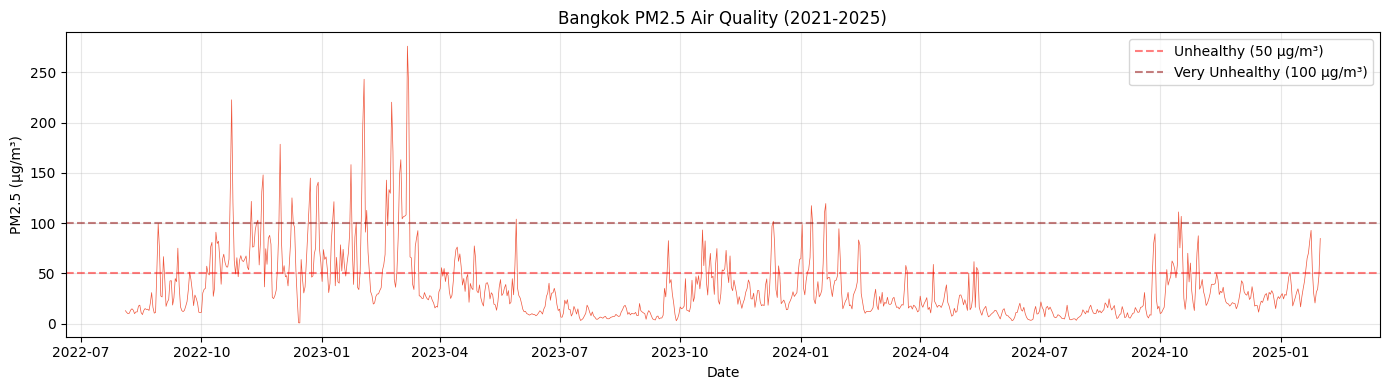

In [10]:
pm25_data = fetch_pm25_data('2021-01-01', '2025-01-31')

if pm25_data is not None:
    print("\nSample PM2.5 data:")
    display(pm25_data.head(10))
    
    plt.figure(figsize=(14, 4))
    plt.plot(pm25_data['date'], pm25_data['pm25_avg'], linewidth=0.5, color='#EF553B')
    plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Unhealthy (50 μg/m³)')
    plt.axhline(y=100, color='darkred', linestyle='--', alpha=0.5, label='Very Unhealthy (100 μg/m³)')
    plt.title('Bangkok PM2.5 Air Quality (2021-2025)')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 (μg/m³)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nFailed to fetch PM2.5 data. Will use simulated data based on historical patterns.")

In [21]:
pm25_data.to_csv('pm25_data.csv')

In [ ]:
rainfall_data = fetch_rainfall_data_meteostat()

Fetching rainfall data from Meteostat...

✓ Rainfall data collected: 1492 days
  Date range: 2021-01-01 00:00:00 to 2025-01-31 00:00:00
  Total rainy days: 1044
  Heavy rain days: 8
  Avg daily rainfall: 4.72 mm


In [20]:
rainfall_data.to_csv('rainfall_data.csv')

In [16]:
rainfall_data

,date,rainfall_mm,rainfall_hours,has_rain,heavy_rain
0,2021-01-01,0.0,0.0,0,0
1,2021-01-02,0.0,0.0,0,0
2,2021-01-03,0.0,0.0,0,0
3,2021-01-04,0.0,0.0,0,0
4,2021-01-05,0.0,0.0,0,0
...,...,...,...,...,...
1487,2025-01-27,0.2,1.0,1,0
1488,2025-01-28,0.0,0.0,0,0
1489,2025-01-29,0.0,0.0,0,0
1490,2025-01-30,0.0,0.0,0,0


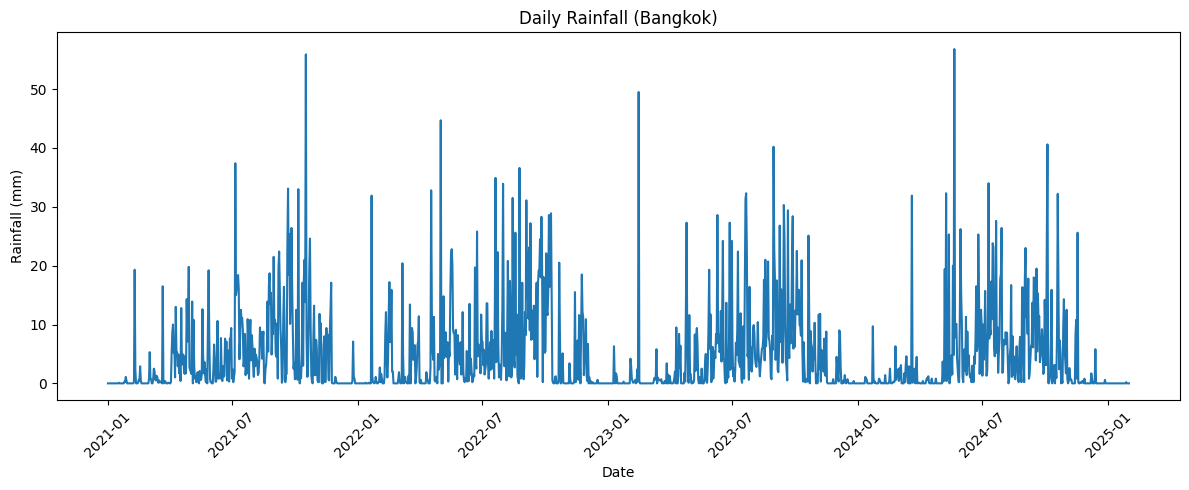

In [ ]:
rainfall_data["date"] = pd.to_datetime(rainfall_data["date"])

plt.figure(figsize=(12,5))
plt.plot(rainfall_data["date"], rainfall_data["rainfall_mm"])

plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.title("Daily Rainfall (Bangkok)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()